# Simulated Annealing, From Scratch\n\nNamed for how metal cools: hot and malleable at first, gradually locking into place as it cools. Simulated annealing (SA) applies the same idea to search — a single point wanders the landscape, and early on (while \"hot\") it will sometimes accept a move that makes things *worse*, on purpose. As the temperature drops, that willingness fades, until eventually it only accepts genuine improvements, just like gradient descent.\n\nThat brief willingness to go backward is the entire trick: it's what lets SA walk back out of a mediocre local minimum before it's committed to it, something plain gradient descent structurally can't do.\n\nThis notebook implements SA from scratch in numpy — no `scipy.optimize.dual_annealing` — and compares it against plain gradient descent, from the *same starting point*, on the Rastrigin function used in the genetic-algorithms notebook.\n\nThe companion interactive version — same comparison, live in the browser — lives at `web/`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor": "#1a1a19",
    "axes.edgecolor": "#383835",
    "axes.labelcolor": "#ffffff",
    "text.color": "#ffffff",
    "xtick.color": "#c3c2b7",
    "ytick.color": "#c3c2b7",
    "grid.color": "#2c2c2a",
    "axes.grid": True,
    "grid.linewidth": 0.5,
    "font.size": 11,
})

A = 10

def rastrigin(x, y):
    return 2 * A + (x**2 - A * np.cos(2 * np.pi * x)) + (y**2 - A * np.cos(2 * np.pi * y))

def rastrigin_grad(x, y):
    dx = 2 * x + 2 * np.pi * A * np.sin(2 * np.pi * x)
    dy = 2 * y + 2 * np.pi * A * np.sin(2 * np.pi * y)
    return dx, dy

grid = np.linspace(-3, 3, 200)
GX, GY = np.meshgrid(grid, grid)
Z = rastrigin(GX, GY)

START = np.array([2.3, 1.8])

## The Metropolis acceptance rule

At each step, propose a random nearby point. If it's better, take it. If it's worse, take it anyway with probability

$$P(\text{accept}) = \exp\left(-\frac{\Delta}{T}\right), \qquad \Delta = f(\text{proposal}) - f(\text{current})$$

At high temperature $T$, this probability is close to 1 even for a fairly bad $\Delta$ — the walk barely cares whether a move helps. As $T \to 0$, the probability collapses to 0 for any $\Delta > 0$ — it becomes indistinguishable from "only accept improvements," i.e. a local hill-climb.

The temperature schedule below decays smoothly from $T_0$ to $T_{\text{final}}$ over the exact number of steps requested (geometric in log-space), so it never "freezes" early regardless of how many steps you ask for.

In [2]:
def run_simulated_annealing(start, steps, t0, t_final, step_scale, seed, bound=3.85):
    rng = np.random.default_rng(seed)
    cooling_rate = (t_final / t0) ** (1 / steps)

    current = np.array(start, dtype=float)
    current_val = rastrigin(*current)
    temp = t0

    path = [current.copy()]
    accepted_worse = [False]
    temps = [temp]

    for _ in range(steps):
        # An unbounded random walk will eventually wander past the plotted grid —
        # clamp proposals to the visible domain (a standard constrained-SA technique).
        proposal = np.clip(current + rng.normal(0, step_scale, size=2), -bound, bound)
        proposal_val = rastrigin(*proposal)
        delta = proposal_val - current_val

        worse = False
        if delta < 0 or rng.uniform() < np.exp(-delta / temp):
            if delta >= 0:
                worse = True
            current = proposal
            current_val = proposal_val

        temp *= cooling_rate
        path.append(current.copy())
        accepted_worse.append(worse)
        temps.append(temp)

    return np.array(path), np.array(accepted_worse), np.array(temps)


def run_gradient_descent(start, lr, steps):
    path = [np.array(start, dtype=float)]
    p = np.array(start, dtype=float)
    for _ in range(steps):
        dx, dy = rastrigin_grad(*p)
        p = p - lr * np.array([dx, dy])
        path.append(p.copy())
    return np.array(path)


STEPS = 400
sa_path, sa_worse, sa_temps = run_simulated_annealing(START, STEPS, t0=15, t_final=0.005, step_scale=0.5, seed=1)
gd_path = run_gradient_descent(START, lr=0.01, steps=STEPS)

print("gradient descent final value:", round(rastrigin(*gd_path[-1]), 3))
print("simulated annealing final value:", round(rastrigin(*sa_path[-1]), 3))
print("uphill moves accepted:", int(sa_worse.sum()), "/", STEPS)

gradient descent final value: 33.738
simulated annealing final value: 2.156
uphill moves accepted: 23 / 400


## The two paths, side by side

Red markers are every move simulated annealing accepted that made things *worse* at that instant.

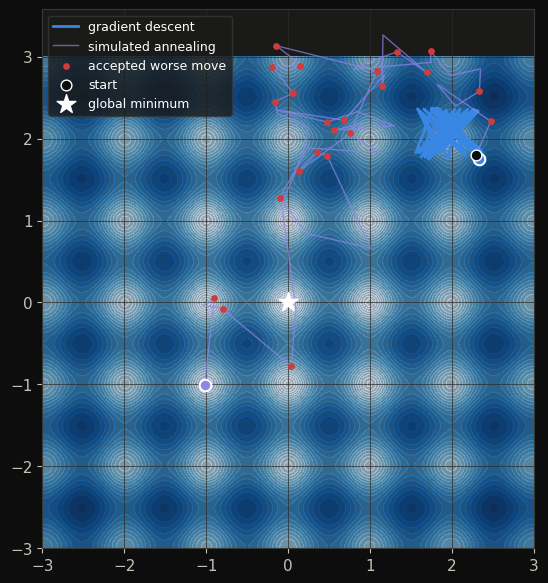

In [3]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.contourf(GX, GY, np.sqrt(Z), levels=25, cmap="Blues", alpha=0.7)

ax.plot(gd_path[:, 0], gd_path[:, 1], color="#3987e5", linewidth=2, label="gradient descent")
ax.scatter(*gd_path[-1], color="#3987e5", s=70, edgecolor="#ffffff", linewidth=1.5, zorder=4)

ax.plot(sa_path[:, 0], sa_path[:, 1], color="#9085e9", linewidth=1, alpha=0.7, label="simulated annealing")
ax.scatter(sa_path[sa_worse, 0], sa_path[sa_worse, 1], color="#d03b3b", s=15, zorder=3, label="accepted worse move")
ax.scatter(*sa_path[-1], color="#9085e9", s=70, edgecolor="#ffffff", linewidth=1.5, zorder=4)

ax.scatter(*START, color="#0d0d0d", edgecolor="#ffffff", s=60, zorder=5, label="start")
ax.scatter(0, 0, color="#ffffff", marker="*", s=200, zorder=5, label="global minimum")

ax.set_aspect("equal")
ax.legend(facecolor="#1a1a19", edgecolor="#383835", labelcolor="#ffffff", loc="upper left", fontsize=9)
plt.show()

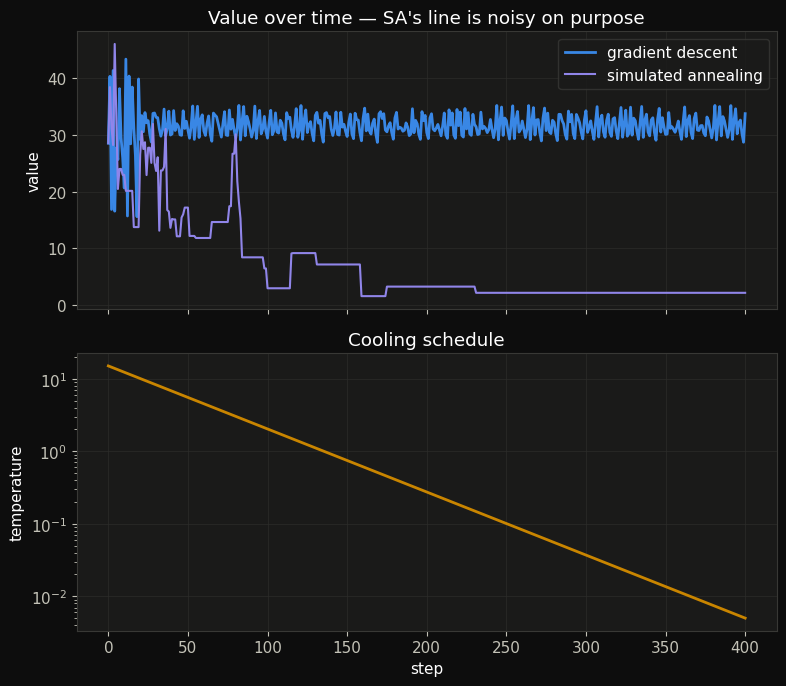

In [4]:
gd_vals = [rastrigin(*p) for p in gd_path]
sa_vals = [rastrigin(*p) for p in sa_path]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

ax1.plot(gd_vals, color="#3987e5", linewidth=2, label="gradient descent")
ax1.plot(sa_vals, color="#9085e9", linewidth=1.5, label="simulated annealing")
ax1.set_ylabel("value")
ax1.set_title("Value over time — SA's line is noisy on purpose")
ax1.legend(facecolor="#1a1a19", edgecolor="#383835", labelcolor="#ffffff")

ax2.plot(sa_temps, color="#c98500", linewidth=2)
ax2.set_ylabel("temperature")
ax2.set_xlabel("step")
ax2.set_yscale("log")
ax2.set_title("Cooling schedule")

plt.tight_layout()
plt.show()

## Takeaways

- Gradient descent and simulated annealing start at the exact same point on the exact same landscape — the only difference is whether the search is ever allowed to move backward.
- The willingness to accept a worse move is temporary by design: it's large early (high $T$) and vanishes late (low $T$), so SA ends its run behaving just like a local hill-climb, having spent its early "hot" phase exploring more broadly.
- The cooling schedule matters more than it looks: cool too fast relative to the step budget and the walk freezes into hill-climbing before it's explored anything (effectively wasting most of the run); cool smoothly across the whole budget and it actually gets to use the temperature range.
- Neither gradient descent nor a single SA run is guaranteed to find the true global optimum — but across this landscape, SA reliably lands far closer than gradient descent ever does, for the same reason the genetic algorithm does: it isn't limited to information about the one spot it currently occupies.